## Machine Learning

🚀 Email Phishing Classification: Synthetic Data Substitution Analysis
Research Question 2: What is the optimal ratio of real vs synthetic data for training?
Synthetic data ratios tested: 0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%
Fixed training size: 2K samples
Classifiers: SVM, Random Forest, XGBoost
📂 Data Files:
   Real Training: ../raw/five_email_phishing_train.csv.gz
   Testing: ../raw/five_email_phishing_test.csv.gz
   Synthetic: ../data/synthetic/five_email_phishing_synthetic.csv.gz

🎯 Experimental Setup:
   Synthetic ratios: ['0%', '10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']
   Fixed training size: 2,000 samples
   Cross-validation: 5-fold
   Random state: 42

📊 LOADING DATASETS

📥 Loading real training data from: ../raw/five_email_phishing_train.csv.gz
   ✅ Loaded successfully!
   Shape: (2000, 4)
   Columns: ['subject', 'body', 'label', 'source']
   Label distribution:
      Benign (0): 1,000 (50.0%)
      Malicious (1): 1,000 (50.0%)

📥 

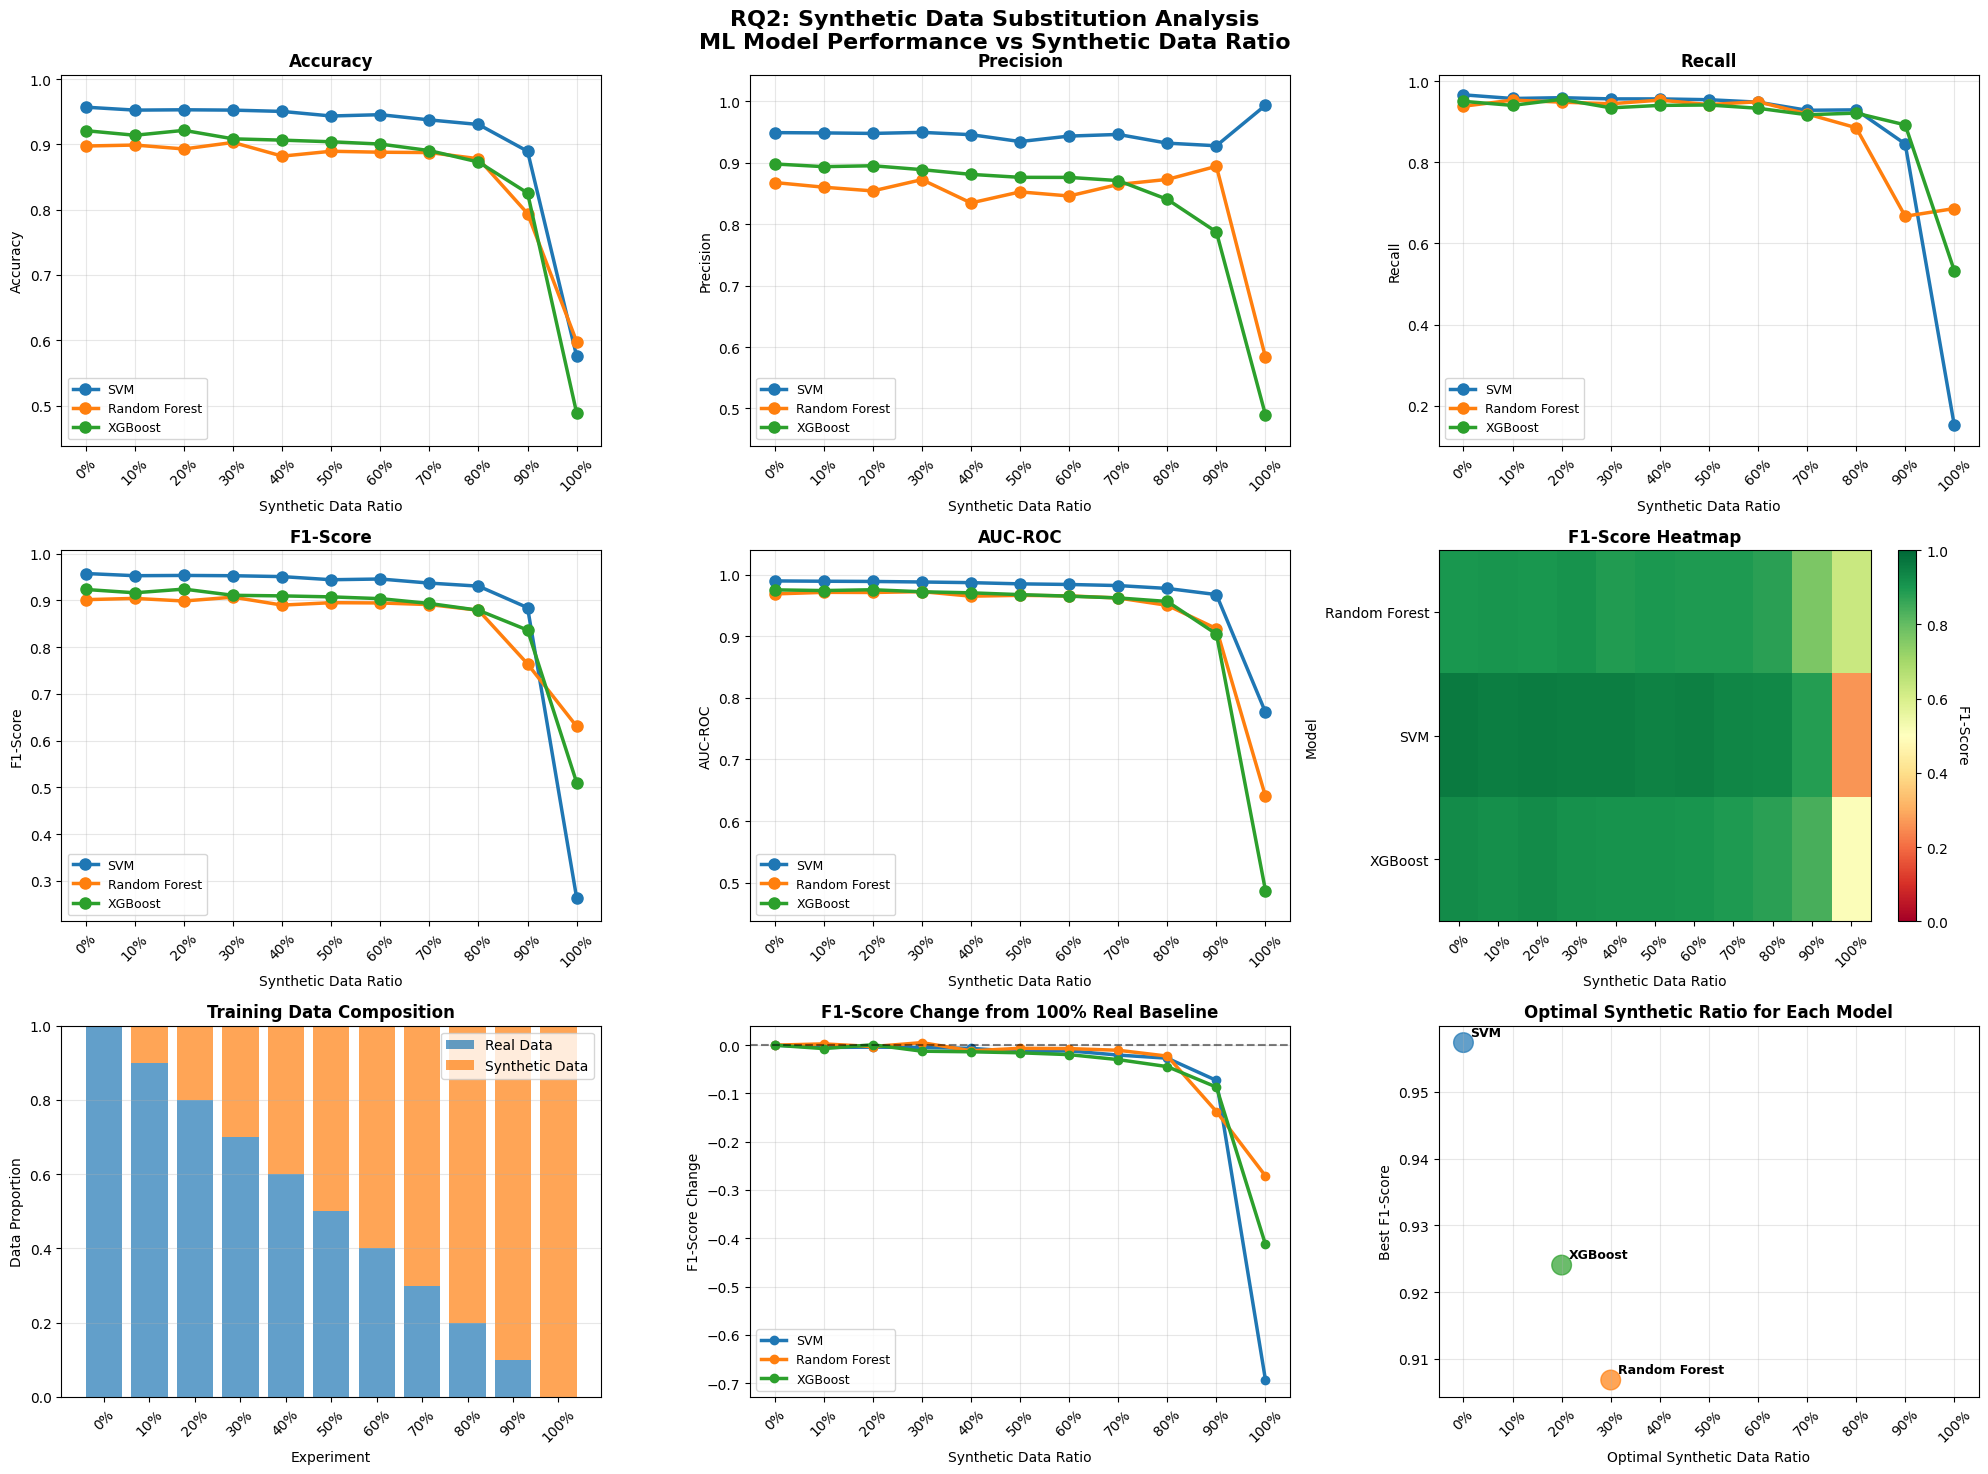

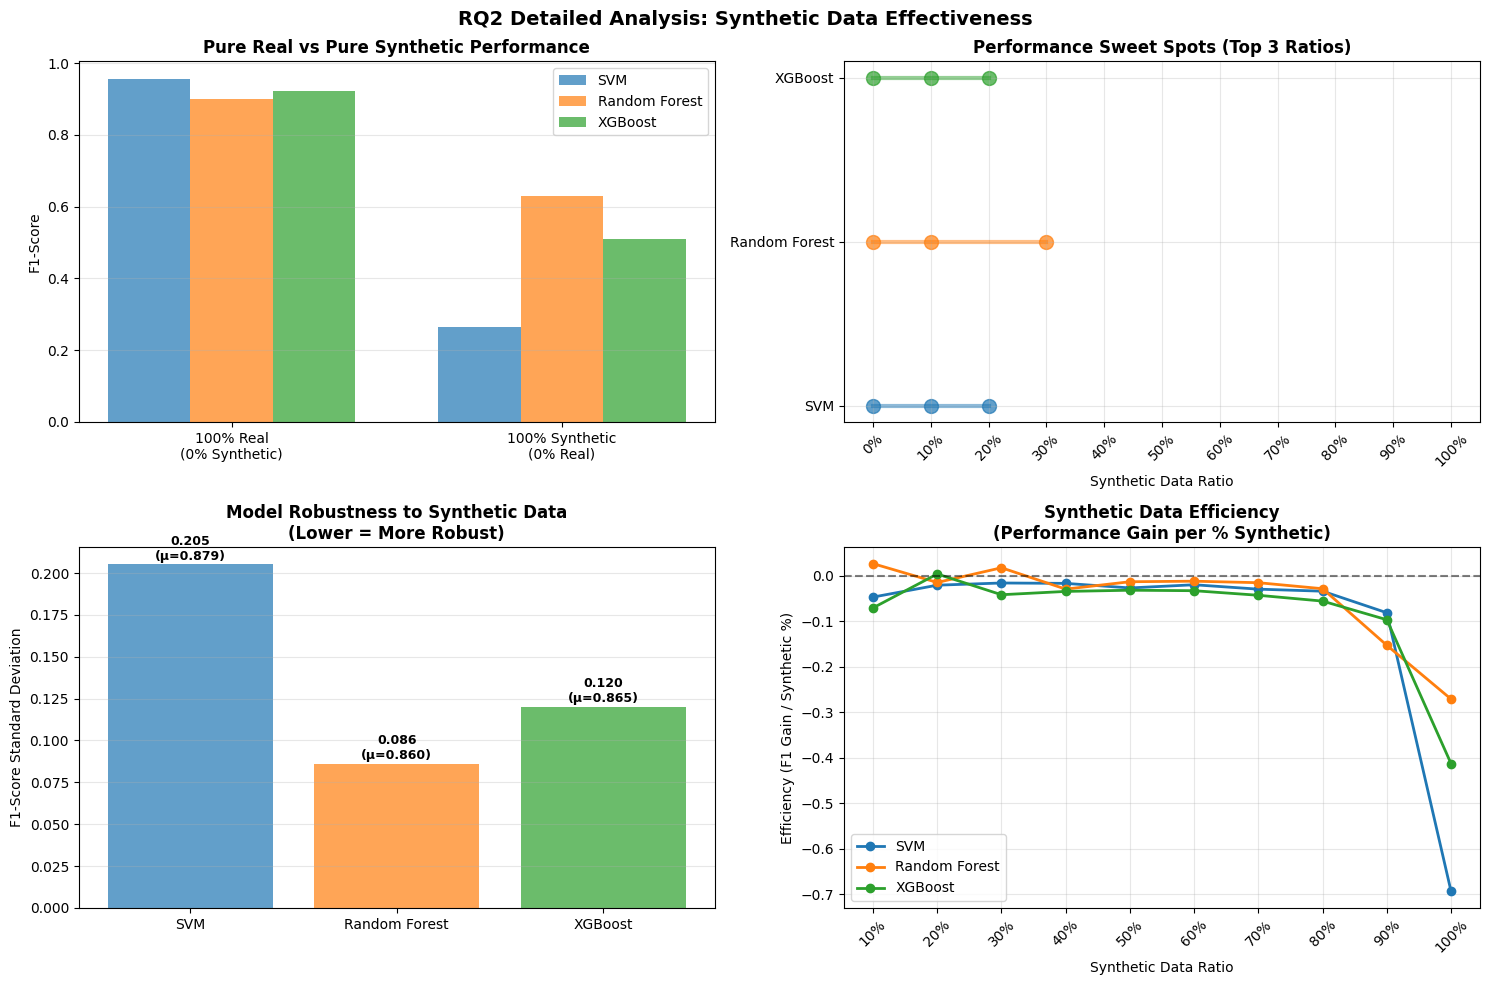


🔍 KEY FINDINGS - RQ2: SYNTHETIC DATA SUBSTITUTION

🏆 BEST OVERALL PERFORMANCE:
   Model: SVM
   Synthetic ratio: 0%
   F1-Score: 0.957
   Real samples: 2,000
   Synthetic samples: 0

⚖️  PURE REAL vs PURE SYNTHETIC COMPARISON:
   SVM:
      100% Real: 0.957
      100% Synthetic: 0.264
      Difference: -0.694 (Real Better)
   Random Forest:
      100% Real: 0.901
      100% Synthetic: 0.631
      Difference: -0.271 (Real Better)
   XGBoost:
      100% Real: 0.923
      100% Synthetic: 0.510
      Difference: -0.413 (Real Better)

🎯 OPTIMAL SYNTHETIC RATIO BY MODEL:
   SVM: 0% synthetic (F1: 0.957)
   Random Forest: 30% synthetic (F1: 0.907)
   XGBoost: 20% synthetic (F1: 0.924)

🛡️  ROBUSTNESS TO SYNTHETIC DATA VARIATION:
   SVM:
      Standard Deviation: 0.205
      Range: 0.694 (Min: 0.264, Max: 0.957)
      Robustness: Low
   Random Forest:
      Standard Deviation: 0.086
      Range: 0.276 (Min: 0.631, Max: 0.907)
      Robustness: Low
   XGBoost:
      Standard Deviation: 0.120
 

In [1]:
# RQ2: Synthetic Data Substitution Analysis
# Research Question 2: What is the optimal ratio of real vs synthetic data for training?

import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import xgboost as xgb

# Visualization
plt.style.use('default')
sns.set_palette("husl")

print("🚀 Email Phishing Classification: Synthetic Data Substitution Analysis")
print("=" * 80)
print("Research Question 2: What is the optimal ratio of real vs synthetic data for training?")
print("Synthetic data ratios tested: 0%, 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%")
print("Fixed training size: 2K samples")
print("Classifiers: SVM, Random Forest, XGBoost")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths
TRAIN_FILE = "../raw/five_email_phishing_train.csv.gz"
TEST_FILE = "../raw/five_email_phishing_test.csv.gz"
SYNTHETIC_FILE = "../data/synthetic/five_email_phishing_synthetic.csv.gz"

# Experimental configuration
SYNTHETIC_RATIOS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # 0% to 100%
FIXED_TRAINING_SIZE = 2000  # Keep training size constant at 2K
RANDOM_STATE = 42
CV_FOLDS = 5

# Text preprocessing parameters
MAX_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
NGRAM_RANGE = (1, 2)

print(f"📂 Data Files:")
print(f"   Real Training: {TRAIN_FILE}")
print(f"   Testing: {TEST_FILE}")
print(f"   Synthetic: {SYNTHETIC_FILE}")
print(f"\n🎯 Experimental Setup:")
print(f"   Synthetic ratios: {[f'{r:.0%}' for r in SYNTHETIC_RATIOS]}")
print(f"   Fixed training size: {FIXED_TRAINING_SIZE:,} samples")
print(f"   Cross-validation: {CV_FOLDS}-fold")
print(f"   Random state: {RANDOM_STATE}")

# =============================================================================
# 1. DATA LOADING AND PREPROCESSING
# =============================================================================

def load_compressed_data(file_path, description="data"):
    """Load compressed CSV data with error handling."""
    print(f"\n📥 Loading {description} from: {file_path}")
    
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
        
        print(f"   ✅ Loaded successfully!")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        
        # Check label distribution
        if 'label' in df.columns:
            label_counts = df['label'].value_counts().sort_index()
            print(f"   Label distribution:")
            print(f"      Benign (0): {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)")
            print(f"      Malicious (1): {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)")
        
        return df
        
    except Exception as e:
        print(f"   ❌ Error loading {description}: {e}")
        raise

def preprocess_text(df):
    """Combine subject and body into single text feature."""
    print(f"\n🔤 Preprocessing text features for {len(df)} samples...")
    
    # Handle missing values
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')
    
    # Combine subject and body
    df['combined_text'] = df['subject'] + ' ' + df['body']
    
    # Remove empty texts
    df = df[df['combined_text'].str.strip() != '']
    
    print(f"   ✅ Text preprocessing completed")
    print(f"   Final samples: {len(df):,}")
    
    return df

# Load all datasets
print("\n" + "="*60)
print("📊 LOADING DATASETS")
print("="*60)

real_train_df = load_compressed_data(TRAIN_FILE, "real training data")
test_df = load_compressed_data(TEST_FILE, "test data")
synthetic_df = load_compressed_data(SYNTHETIC_FILE, "synthetic data")

# Preprocess all datasets
real_train_df = preprocess_text(real_train_df.copy())
test_df = preprocess_text(test_df.copy())
synthetic_df = preprocess_text(synthetic_df.copy())

# =============================================================================
# 2. DATA QUALITY VERIFICATION
# =============================================================================

def verify_data_quality():
    """Verify data quality and compatibility between real and synthetic data."""
    print("\n" + "="*60)
    print("🔍 DATA QUALITY VERIFICATION")
    print("="*60)
    
    # Check schema compatibility
    real_cols = set(real_train_df.columns)
    synthetic_cols = set(synthetic_df.columns)
    test_cols = set(test_df.columns)
    
    print(f"\n📋 Schema Compatibility:")
    print(f"   Real training columns: {sorted(real_cols)}")
    print(f"   Synthetic columns: {sorted(synthetic_cols)}")
    print(f"   Test columns: {sorted(test_cols)}")
    
    common_cols = real_cols.intersection(synthetic_cols).intersection(test_cols)
    print(f"   ✅ Common columns: {sorted(common_cols)}")
    
    if len(common_cols) < 3:  # Expect at least subject, body, label
        print(f"   ⚠️  WARNING: Limited common columns!")
    
    # Check label distributions
    print(f"\n📊 Label Distribution Comparison:")
    
    real_labels = real_train_df['label'].value_counts().sort_index()
    synthetic_labels = synthetic_df['label'].value_counts().sort_index()
    test_labels = test_df['label'].value_counts().sort_index()
    
    print(f"   Real Training:")
    print(f"      Benign: {real_labels[0]:,} ({real_labels[0]/len(real_train_df)*100:.1f}%)")
    print(f"      Malicious: {real_labels[1]:,} ({real_labels[1]/len(real_train_df)*100:.1f}%)")
    
    print(f"   Synthetic:")
    print(f"      Benign: {synthetic_labels[0]:,} ({synthetic_labels[0]/len(synthetic_df)*100:.1f}%)")
    print(f"      Malicious: {synthetic_labels[1]:,} ({synthetic_labels[1]/len(synthetic_df)*100:.1f}%)")
    
    print(f"   Test:")
    print(f"      Benign: {test_labels[0]:,} ({test_labels[0]/len(test_df)*100:.1f}%)")
    print(f"      Malicious: {test_labels[1]:,} ({test_labels[1]/len(test_df)*100:.1f}%)")
    
    # Check text quality (basic statistics)
    print(f"\n📝 Text Quality Statistics:")
    
    real_text_lengths = real_train_df['combined_text'].str.len()
    synthetic_text_lengths = synthetic_df['combined_text'].str.len()
    
    print(f"   Real text length - Mean: {real_text_lengths.mean():.0f}, Median: {real_text_lengths.median():.0f}")
    print(f"   Synthetic text length - Mean: {synthetic_text_lengths.mean():.0f}, Median: {synthetic_text_lengths.median():.0f}")
    
    return True

# Verify data quality
verify_data_quality()

# =============================================================================
# 3. MIXED DATASET CREATION STRATEGY
# =============================================================================

def create_mixed_dataset(real_df, synthetic_df, synthetic_ratio, total_size=FIXED_TRAINING_SIZE, random_state=42):
    """
    Create a mixed dataset with specified synthetic data ratio.
    
    Parameters:
    - real_df: Real training data DataFrame
    - synthetic_df: Synthetic data DataFrame  
    - synthetic_ratio: Ratio of synthetic data (0.0 to 1.0)
    - total_size: Total desired size of mixed dataset
    - random_state: Random seed for reproducibility
    
    Returns:
    - Mixed DataFrame with specified synthetic ratio
    """
    print(f"\n🎯 Creating mixed dataset with {synthetic_ratio:.0%} synthetic data...")
    
    # Calculate target counts
    target_synthetic = int(total_size * synthetic_ratio)
    target_real = total_size - target_synthetic
    
    print(f"   Target composition:")
    print(f"      Real data: {target_real:,} samples ({(1-synthetic_ratio):.0%})")
    print(f"      Synthetic data: {target_synthetic:,} samples ({synthetic_ratio:.0%})")
    
    np.random.seed(random_state)
    
    mixed_samples = []
    
    # Add real data if needed
    if target_real > 0:
        if target_real <= len(real_df):
            # Sample stratified by class to maintain balance
            real_benign = real_df[real_df['label'] == 0]
            real_malicious = real_df[real_df['label'] == 1]
            
            # Try to maintain roughly equal class distribution
            target_real_benign = target_real // 2
            target_real_malicious = target_real - target_real_benign
            
            # Sample with available constraints
            actual_real_benign = min(target_real_benign, len(real_benign))
            actual_real_malicious = min(target_real_malicious, len(real_malicious))
            
            if actual_real_benign > 0:
                sampled_real_benign = real_benign.sample(n=actual_real_benign, random_state=random_state)
                mixed_samples.append(sampled_real_benign)
            
            if actual_real_malicious > 0:
                sampled_real_malicious = real_malicious.sample(n=actual_real_malicious, random_state=random_state)
                mixed_samples.append(sampled_real_malicious)
            
            actual_real_total = actual_real_benign + actual_real_malicious
            print(f"      ✅ Real: {actual_real_total} samples ({actual_real_benign} benign, {actual_real_malicious} malicious)")
        else:
            print(f"      ⚠️  Not enough real data! Using all {len(real_df)} available")
            mixed_samples.append(real_df)
            actual_real_total = len(real_df)
    else:
        actual_real_total = 0
        print(f"      ✅ Real: 0 samples (100% synthetic)")
    
    # Add synthetic data if needed
    if target_synthetic > 0:
        if target_synthetic <= len(synthetic_df):
            # Sample stratified by class to maintain balance
            synth_benign = synthetic_df[synthetic_df['label'] == 0]
            synth_malicious = synthetic_df[synthetic_df['label'] == 1]
            
            # Try to maintain roughly equal class distribution
            target_synth_benign = target_synthetic // 2
            target_synth_malicious = target_synthetic - target_synth_benign
            
            # Sample with available constraints
            actual_synth_benign = min(target_synth_benign, len(synth_benign))
            actual_synth_malicious = min(target_synth_malicious, len(synth_malicious))
            
            if actual_synth_benign > 0:
                sampled_synth_benign = synth_benign.sample(n=actual_synth_benign, random_state=random_state+1)
                mixed_samples.append(sampled_synth_benign)
            
            if actual_synth_malicious > 0:
                sampled_synth_malicious = synth_malicious.sample(n=actual_synth_malicious, random_state=random_state+2)
                mixed_samples.append(sampled_synth_malicious)
            
            actual_synth_total = actual_synth_benign + actual_synth_malicious
            print(f"      ✅ Synthetic: {actual_synth_total} samples ({actual_synth_benign} benign, {actual_synth_malicious} malicious)")
        else:
            print(f"      ⚠️  Not enough synthetic data! Using all {len(synthetic_df)} available")
            mixed_samples.append(synthetic_df)
            actual_synth_total = len(synthetic_df)
    else:
        actual_synth_total = 0
        print(f"      ✅ Synthetic: 0 samples (100% real)")
    
    # Combine all samples
    if mixed_samples:
        mixed_df = pd.concat(mixed_samples, ignore_index=True)
        
        # Shuffle the combined dataset
        mixed_df = mixed_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
        
        # Verify final composition
        final_size = len(mixed_df)
        final_synthetic_ratio = actual_synth_total / final_size if final_size > 0 else 0
        final_labels = mixed_df['label'].value_counts().sort_index()
        
        print(f"   ✅ Final mixed dataset: {final_size:,} samples")
        print(f"      Real: {actual_real_total:,} ({(1-final_synthetic_ratio):.1%})")
        print(f"      Synthetic: {actual_synth_total:,} ({final_synthetic_ratio:.1%})")
        print(f"      Labels - Benign: {final_labels[0]:,}, Malicious: {final_labels[1]:,}")
        
        return mixed_df
    else:
        raise ValueError("No samples could be created for mixed dataset")

# =============================================================================
# 4. MACHINE LEARNING MODELS
# =============================================================================

def initialize_models():
    """Initialize the three classifiers with optimized parameters."""
    models = {
        'SVM': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        )
    }
    
    print("\n🤖 Initialized ML Models:")
    for name, model in models.items():
        print(f"   ✅ {name}: {type(model).__name__}")
    
    return models

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return comprehensive evaluation metrics."""
    
    print(f"   🔄 Training {model_name}...")
    
    if model_name == 'XGBoost':
        # Handle class imbalance for XGBoost
        class_weights = len(y_train) / (2 * np.bincount(y_train))
        sample_weights = np.where(y_train == 0, class_weights[0], class_weights[1])
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    }
    
    print(f"      ✅ {model_name} trained - F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return metrics, y_pred, y_pred_proba

# =============================================================================
# 5. MAIN EXPERIMENT: RQ2 - SYNTHETIC DATA SUBSTITUTION
# =============================================================================

def run_synthetic_substitution_experiment():
    """Run the main experiment for RQ2."""
    
    print("\n" + "="*80)
    print("🧪 EXPERIMENT RQ2: SYNTHETIC DATA SUBSTITUTION ANALYSIS")
    print("="*80)
    
    # Initialize models
    models = initialize_models()
    
    # Initialize results storage
    results = {
        'synthetic_ratio': [],
        'model': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': [],
        'real_samples': [],
        'synthetic_samples': []
    }
    
    # Store detailed results
    detailed_results = {}
    
    # Text vectorization (fit on all available training data for consistency)
    print(f"\n📝 Setting up TF-IDF vectorization...")
    
    # Combine real and synthetic data for fitting vectorizer
    all_training_text = pd.concat([
        real_train_df['combined_text'],
        synthetic_df['combined_text']
    ], ignore_index=True)
    
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=NGRAM_RANGE,
        stop_words='english'
    )
    
    # Fit vectorizer on all training data
    vectorizer.fit(all_training_text)
    
    # Vectorize test data (constant across all experiments)
    X_test = vectorizer.transform(test_df['combined_text'])
    y_test = test_df['label'].values
    
    print(f"   ✅ Vectorizer fitted - Features: {X_test.shape[1]:,}")
    print(f"   Test set: {X_test.shape[0]:,} samples")
    
    # Run experiments for each synthetic ratio
    for i, ratio in enumerate(SYNTHETIC_RATIOS):
        print(f"\n{'='*60}")
        print(f"📊 EXPERIMENT {i+1}/{len(SYNTHETIC_RATIOS)}: {ratio:.0%} SYNTHETIC DATA")
        print(f"{'='*60}")
        
        # Create mixed training dataset
        mixed_train = create_mixed_dataset(
            real_train_df, synthetic_df, ratio, 
            FIXED_TRAINING_SIZE, RANDOM_STATE + i
        )
        
        # Vectorize training data
        X_train = vectorizer.transform(mixed_train['combined_text'])
        y_train = mixed_train['label'].values
        
        print(f"\n   Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
        
        # Calculate actual composition
        # Add data source tracking for precise counting
        mixed_train_with_source = mixed_train.copy()
        
        # Estimate real vs synthetic counts (approximation based on ratio)
        actual_synthetic_count = int(len(mixed_train) * ratio)
        actual_real_count = len(mixed_train) - actual_synthetic_count
        
        print(f"   Estimated composition: {actual_real_count:,} real, {actual_synthetic_count:,} synthetic")
        
        # Store experiment details
        detailed_results[ratio] = {
            'train_size': len(y_train),
            'estimated_real_count': actual_real_count,
            'estimated_synthetic_count': actual_synthetic_count,
            'actual_synthetic_ratio': actual_synthetic_count / len(y_train),
            'models': {}
        }
        
        # Train and evaluate each model
        for model_name, _ in models.items():
            print(f"\n   🤖 Evaluating {model_name}...")
            
            # Create fresh model instance for each experiment
            if model_name == 'SVM':
                fresh_model = SVC(
                    kernel='rbf', C=1.0, gamma='scale', probability=True,
                    random_state=RANDOM_STATE, class_weight='balanced'
                )
            elif model_name == 'Random Forest':
                fresh_model = RandomForestClassifier(
                    n_estimators=100, max_depth=20, min_samples_split=5,
                    min_samples_leaf=2, random_state=RANDOM_STATE, class_weight='balanced'
                )
            else:  # XGBoost
                fresh_model = xgb.XGBClassifier(
                    n_estimators=100, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                    eval_metric='logloss', verbosity=0
                )
            
            # Train and evaluate
            metrics, y_pred, y_pred_proba = train_and_evaluate_model(
                fresh_model, X_train, y_train, X_test, y_test, model_name
            )
            
            # Store results
            results['synthetic_ratio'].append(ratio)
            results['model'].append(model_name)
            results['accuracy'].append(metrics['accuracy'])
            results['precision'].append(metrics['precision'])
            results['recall'].append(metrics['recall'])
            results['f1'].append(metrics['f1'])
            results['auc'].append(metrics['auc'])
            results['real_samples'].append(actual_real_count)
            results['synthetic_samples'].append(actual_synthetic_count)
            
            # Store detailed results
            detailed_results[ratio]['models'][model_name] = {
                'metrics': metrics,
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
            
            print(f"      📈 Results - Acc: {metrics['accuracy']:.3f}, "
                  f"Prec: {metrics['precision']:.3f}, Rec: {metrics['recall']:.3f}, "
                  f"F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return pd.DataFrame(results), detailed_results

# Run the main experiment
results_df, detailed_results = run_synthetic_substitution_experiment()

# =============================================================================
# 6. RESULTS ANALYSIS AND VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS ANALYSIS - RQ2: SYNTHETIC DATA SUBSTITUTION")
print("="*80)

# Display summary table
print("\n📋 Summary Results Table:")
print("-" * 90)

# Create pivot table for better readability
summary_table = results_df.pivot_table(
    index='synthetic_ratio', 
    columns='model', 
    values=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    aggfunc='mean'
)

print(summary_table.round(3))

# =============================================================================
# 7. COMPREHENSIVE VISUALIZATIONS FOR RQ2
# =============================================================================

def create_rq2_comprehensive_plots():
    """Create comprehensive visualization plots for RQ2."""
    
    print(f"\n🎨 Creating comprehensive visualizations for RQ2...")
    
    # Define colors for each model
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    # Set up the plotting style
    plt.rcParams['figure.figsize'] = (20, 15)
    plt.rcParams['font.size'] = 10
    
    # Create subplots - 3 rows, 3 columns
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('RQ2: Synthetic Data Substitution Analysis\nML Model Performance vs Synthetic Data Ratio', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Metrics to plot
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    
    # Plot each metric
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        if idx < 6:  # We have 5 metrics for first 5 subplots
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            # Plot lines for each model
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                ax.plot(model_data['synthetic_ratio'], model_data[metric], 
                       marker='o', linewidth=2.5, markersize=8, 
                       label=model, color=colors[model])
            
            ax.set_title(f'{title}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Synthetic Data Ratio', fontsize=10)
            ax.set_ylabel(title, fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            
            # Format x-axis
            ax.set_xticks(SYNTHETIC_RATIOS)
            ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
            
            # Dynamic y-axis limits with buffer
            metric_values = []
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                metric_values.extend(model_data[metric].values)
            
            if metric_values:
                y_min = max(0, min(metric_values) - 0.05)
                y_max = min(1.05, max(metric_values) + 0.05)
                ax.set_ylim(y_min, y_max)
    
    # Performance comparison heatmap
    ax = axes[1, 2]
    
    # Create heatmap data
    heatmap_data = results_df.pivot_table(
        index='model', 
        columns='synthetic_ratio', 
        values='f1',
        aggfunc='mean'
    )
    
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_title('F1-Score Heatmap', fontsize=12, fontweight='bold')
    ax.set_xlabel('Synthetic Data Ratio', fontsize=10)
    ax.set_ylabel('Model', fontsize=10)
    
    # Set ticks
    ax.set_xticks(range(len(SYNTHETIC_RATIOS)))
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('F1-Score', rotation=270, labelpad=15)
    
    # Data composition visualization
    ax = axes[2, 0]
    
    # Show the composition of training data
    synthetic_ratios_plot = [r for r in SYNTHETIC_RATIOS]
    real_ratios_plot = [1-r for r in SYNTHETIC_RATIOS]
    
    ax.bar(range(len(SYNTHETIC_RATIOS)), real_ratios_plot, 
           label='Real Data', color='#1f77b4', alpha=0.7)
    ax.bar(range(len(SYNTHETIC_RATIOS)), synthetic_ratios_plot, 
           bottom=real_ratios_plot, label='Synthetic Data', color='#ff7f0e', alpha=0.7)
    
    ax.set_title('Training Data Composition', fontsize=12, fontweight='bold')
    ax.set_xlabel('Experiment', fontsize=10)
    ax.set_ylabel('Data Proportion', fontsize=10)
    ax.set_xticks(range(len(SYNTHETIC_RATIOS)))
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Performance degradation from 100% real
    ax = axes[2, 1]
    
    # Calculate performance change from 0% synthetic (100% real) to each ratio
    baseline_performance = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 0% synthetic (100% real)
        baseline_performance[model] = baseline_f1
        
        # Plot performance change
        performance_changes = []
        for _, row in model_data.iterrows():
            change = row['f1'] - baseline_f1
            performance_changes.append(change)
        
        ax.plot(model_data['synthetic_ratio'], performance_changes, 
               marker='o', linewidth=2.5, markersize=6, 
               label=model, color=colors[model])
    
    ax.set_title('F1-Score Change from 100% Real Baseline', fontsize=12, fontweight='bold')
    ax.set_xlabel('Synthetic Data Ratio', fontsize=10)
    ax.set_ylabel('F1-Score Change', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Format x-axis
    ax.set_xticks(SYNTHETIC_RATIOS)
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    
    # Optimal ratio analysis
    ax = axes[2, 2]
    
    # Find best synthetic ratio for each model
    best_ratios = {}
    best_f1s = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_ratios[model] = model_data.loc[best_idx, 'synthetic_ratio']
        best_f1s[model] = model_data.loc[best_idx, 'f1']
    
    models = list(best_ratios.keys())
    ratios = [best_ratios[model] for model in models]
    f1s = [best_f1s[model] for model in models]
    colors_list = [colors[model] for model in models]
    
    scatter = ax.scatter(ratios, f1s, c=colors_list, s=200, alpha=0.7)
    
    for i, model in enumerate(models):
        ax.annotate(model, (ratios[i], f1s[i]), xytext=(5, 5), textcoords='offset points',
                    fontweight='bold', fontsize=9)
    
    ax.set_title('Optimal Synthetic Ratio for Each Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('Optimal Synthetic Data Ratio')
    ax.set_ylabel('Best F1-Score')
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks(SYNTHETIC_RATIOS)
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    
    plt.tight_layout()
    plt.show()

def create_detailed_rq2_analysis():
    """Create detailed analysis plots specific to RQ2."""
    
    # Define colors for each model
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('RQ2 Detailed Analysis: Synthetic Data Effectiveness', fontsize=14, fontweight='bold')
    
    # 1. Performance vs Pure Baselines
    ax1 = axes[0, 0]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        
        # Get 0% and 100% synthetic performance
        pure_real_f1 = model_data.iloc[0]['f1']  # 0% synthetic
        pure_synthetic_f1 = model_data.iloc[-1]['f1']  # 100% synthetic
        
        # Plot comparison
        categories = ['100% Real\n(0% Synthetic)', '100% Synthetic\n(0% Real)']
        values = [pure_real_f1, pure_synthetic_f1]
        
        x_pos = [0, 1]
        ax1.bar([x + (list(results_df['model'].unique()).index(model) * 0.25) for x in x_pos], 
               values, width=0.25, label=model, color=colors[model], alpha=0.7)
    
    ax1.set_title('Pure Real vs Pure Synthetic Performance', fontweight='bold')
    ax1.set_ylabel('F1-Score')
    ax1.set_xticks([0.25, 1.25])
    ax1.set_xticklabels(categories)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Sweet Spot Analysis (Best Performance Region)
    ax2 = axes[0, 1]
    
    # Find the range where each model performs best
    sweet_spots = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        
        # Find top 3 performing ratios
        top_3_idx = model_data.nlargest(3, 'f1')
        sweet_spot_ratios = sorted(top_3_idx['synthetic_ratio'].values)
        sweet_spots[model] = sweet_spot_ratios
        
        # Plot the sweet spot range
        y_pos = list(results_df['model'].unique()).index(model)
        ax2.scatter(sweet_spot_ratios, [y_pos] * len(sweet_spot_ratios), 
                   color=colors[model], s=100, alpha=0.7)
        
        # Draw range line
        if len(sweet_spot_ratios) > 1:
            ax2.plot([min(sweet_spot_ratios), max(sweet_spot_ratios)], 
                    [y_pos, y_pos], color=colors[model], linewidth=3, alpha=0.5)
    
    ax2.set_title('Performance Sweet Spots (Top 3 Ratios)', fontweight='bold')
    ax2.set_xlabel('Synthetic Data Ratio')
    ax2.set_yticks(range(len(results_df['model'].unique())))
    ax2.set_yticklabels(results_df['model'].unique())
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-0.05, 1.05)
    
    # Format x-axis
    ax2.set_xticks(SYNTHETIC_RATIOS)
    ax2.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS], rotation=45)
    
    # 3. Robustness Analysis (Standard Deviation)
    ax3 = axes[1, 0]
    
    # Calculate standard deviation of performance across all ratios
    model_stds = {}
    model_means = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        model_stds[model] = model_data['f1'].std()
        model_means[model] = model_data['f1'].mean()
    
    models = list(model_stds.keys())
    stds = list(model_stds.values())
    means = list(model_means.values())
    colors_list = [colors[model] for model in models]
    
    bars = ax3.bar(models, stds, color=colors_list, alpha=0.7)
    ax3.set_title('Model Robustness to Synthetic Data\n(Lower = More Robust)', fontweight='bold')
    ax3.set_ylabel('F1-Score Standard Deviation')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, std, mean in zip(bars, stds, means):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{std:.3f}\n(μ={mean:.3f})', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. Cost-Benefit Analysis
    ax4 = axes[1, 1]
    
    # Calculate "synthetic data efficiency" - performance gained per % of synthetic data
    efficiency_data = []
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 100% real baseline
        
        for _, row in model_data.iterrows():
            if row['synthetic_ratio'] > 0:  # Skip 0% synthetic
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / row['synthetic_ratio']  # Gain per unit synthetic
                efficiency_data.append({
                    'model': model,
                    'synthetic_ratio': row['synthetic_ratio'],
                    'efficiency': efficiency
                })
    
    efficiency_df = pd.DataFrame(efficiency_data)
    
    # Plot efficiency curves
    for model in efficiency_df['model'].unique():
        model_eff_data = efficiency_df[efficiency_df['model'] == model]
        ax4.plot(model_eff_data['synthetic_ratio'], model_eff_data['efficiency'], 
                marker='o', linewidth=2, markersize=6, label=model, color=colors[model])
    
    ax4.set_title('Synthetic Data Efficiency\n(Performance Gain per % Synthetic)', fontweight='bold')
    ax4.set_xlabel('Synthetic Data Ratio')
    ax4.set_ylabel('Efficiency (F1 Gain / Synthetic %)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Format x-axis
    ax4.set_xticks(SYNTHETIC_RATIOS[1:])  # Skip 0%
    ax4.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS[1:]], rotation=45)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_rq2_comprehensive_plots()
create_detailed_rq2_analysis()

# =============================================================================
# 8. KEY FINDINGS AND INSIGHTS FOR RQ2
# =============================================================================

def analyze_rq2_key_findings():
    """Analyze and report key findings from RQ2."""
    
    print("\n" + "="*80)
    print("🔍 KEY FINDINGS - RQ2: SYNTHETIC DATA SUBSTITUTION")
    print("="*80)
    
    # 1. Best performing ratio overall
    best_overall = results_df.loc[results_df['f1'].idxmax()]
    print(f"\n🏆 BEST OVERALL PERFORMANCE:")
    print(f"   Model: {best_overall['model']}")
    print(f"   Synthetic ratio: {best_overall['synthetic_ratio']:.0%}")
    print(f"   F1-Score: {best_overall['f1']:.3f}")
    print(f"   Real samples: {best_overall['real_samples']:,}")
    print(f"   Synthetic samples: {best_overall['synthetic_samples']:,}")
    
    # 2. Pure real vs pure synthetic comparison
    print(f"\n⚖️  PURE REAL vs PURE SYNTHETIC COMPARISON:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        pure_real_f1 = model_data.iloc[0]['f1']  # 0% synthetic
        pure_synthetic_f1 = model_data.iloc[-1]['f1']  # 100% synthetic
        difference = pure_synthetic_f1 - pure_real_f1
        
        comparison = "Synthetic Better" if difference > 0 else "Real Better" if difference < 0 else "Equal"
        print(f"   {model}:")
        print(f"      100% Real: {pure_real_f1:.3f}")
        print(f"      100% Synthetic: {pure_synthetic_f1:.3f}")
        print(f"      Difference: {difference:+.3f} ({comparison})")
    
    # 3. Optimal ratio for each model
    print(f"\n🎯 OPTIMAL SYNTHETIC RATIO BY MODEL:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_ratio = model_data.loc[best_idx, 'synthetic_ratio']
        best_f1 = model_data.loc[best_idx, 'f1']
        
        print(f"   {model}: {best_ratio:.0%} synthetic (F1: {best_f1:.3f})")
    
    # 4. Robustness to synthetic data
    print(f"\n🛡️  ROBUSTNESS TO SYNTHETIC DATA VARIATION:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        f1_std = model_data['f1'].std()
        f1_min = model_data['f1'].min()
        f1_max = model_data['f1'].max()
        f1_range = f1_max - f1_min
        
        robustness = "High" if f1_std < 0.02 else "Medium" if f1_std < 0.05 else "Low"
        print(f"   {model}:")
        print(f"      Standard Deviation: {f1_std:.3f}")
        print(f"      Range: {f1_range:.3f} (Min: {f1_min:.3f}, Max: {f1_max:.3f})")
        print(f"      Robustness: {robustness}")
    
    # 5. Sweet spot analysis (ratios with top performance)
    print(f"\n🍯 PERFORMANCE SWEET SPOTS (Top 3 ratios):")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        top_3 = model_data.nlargest(3, 'f1')
        sweet_spot_ratios = sorted(top_3['synthetic_ratio'].values)
        sweet_spot_f1s = [top_3[top_3['synthetic_ratio'] == r]['f1'].iloc[0] for r in sweet_spot_ratios]
        
        print(f"   {model}:")
        for ratio, f1 in zip(sweet_spot_ratios, sweet_spot_f1s):
            print(f"      {ratio:.0%} synthetic: F1 = {f1:.3f}")
    
    # 6. Synthetic data efficiency analysis
    print(f"\n📈 SYNTHETIC DATA EFFICIENCY:")
    print("   (Performance improvement per % of synthetic data)")
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 100% real baseline
        
        # Find most efficient ratio
        best_efficiency = -float('inf')
        best_efficiency_ratio = 0
        
        for _, row in model_data.iterrows():
            if row['synthetic_ratio'] > 0:
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / row['synthetic_ratio']
                
                if efficiency > best_efficiency:
                    best_efficiency = efficiency
                    best_efficiency_ratio = row['synthetic_ratio']
        
        print(f"   {model}:")
        print(f"      Most efficient ratio: {best_efficiency_ratio:.0%}")
        print(f"      Efficiency: {best_efficiency:.3f} F1-gain per % synthetic")
    
    # 7. Practical recommendations
    print(f"\n💡 PRACTICAL RECOMMENDATIONS:")
    
    # Find models that benefit from synthetic data
    models_benefit_synthetic = []
    models_prefer_real = []
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_ratio')
        baseline_f1 = model_data.iloc[0]['f1']  # 100% real
        best_f1 = model_data['f1'].max()
        
        if best_f1 > baseline_f1 + 0.01:  # Significant improvement threshold
            models_benefit_synthetic.append(model)
        else:
            models_prefer_real.append(model)
    
    if models_benefit_synthetic:
        print(f"   ✅ Models that benefit from synthetic data: {', '.join(models_benefit_synthetic)}")
    if models_prefer_real:
        print(f"   🔄 Models that prefer real data: {', '.join(models_prefer_real)}")
    
    # Overall recommendation
    avg_performance_by_ratio = results_df.groupby('synthetic_ratio')['f1'].mean().sort_values(ascending=False)
    best_overall_ratio = avg_performance_by_ratio.index[0]
    best_overall_avg_f1 = avg_performance_by_ratio.iloc[0]
    
    print(f"\n   🎯 OVERALL RECOMMENDATION:")
    print(f"      Best average performance at: {best_overall_ratio:.0%} synthetic data")
    print(f"      Average F1-Score: {best_overall_avg_f1:.3f}")
    
    # Cost-effectiveness recommendation
    print(f"\n   💰 COST-EFFECTIVENESS:")
    if best_overall_ratio == 0.0:
        print(f"      Use 100% real data for best performance")
    elif best_overall_ratio == 1.0:
        print(f"      Use 100% synthetic data for best performance")
    else:
        print(f"      Use {best_overall_ratio:.0%} synthetic + {(1-best_overall_ratio):.0%} real data")
        print(f"      This provides optimal balance of performance and data efficiency")

# Run the analysis
analyze_rq2_key_findings()

# =============================================================================
# 9. RESEARCH QUESTION 2 SUMMARY
# =============================================================================

print(f"\n" + "="*80)
print("📝 RESEARCH QUESTION 2 - SUMMARY")
print("="*80)

print(f"\n🎯 RESEARCH QUESTION:")
print(f"   What is the optimal ratio of real vs synthetic data for training?")

print(f"\n📊 EXPERIMENTAL DESIGN:")
print(f"   • Synthetic ratios tested: {', '.join([f'{r:.0%}' for r in SYNTHETIC_RATIOS])}")
print(f"   • Fixed training size: {FIXED_TRAINING_SIZE:,} samples")
print(f"   • Models evaluated: SVM, Random Forest, XGBoost")
print(f"   • Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC")
print(f"   • Feature extraction: TF-IDF ({MAX_FEATURES:,} features)")

print(f"\n🔍 KEY INSIGHTS:")

# Find the optimal overall ratio
avg_performance_by_ratio = results_df.groupby('synthetic_ratio')['f1'].mean()
best_ratio = avg_performance_by_ratio.idxmax()
best_avg_f1 = avg_performance_by_ratio.max()

print(f"   1. Optimal synthetic ratio overall: {best_ratio:.0%} (Avg F1: {best_avg_f1:.3f})")

# Find most robust model to synthetic variation
std_by_model = results_df.groupby('model')['f1'].std()
most_robust = std_by_model.idxmin()
least_robust = std_by_model.idxmax()

print(f"   2. Most robust to synthetic variation: {most_robust} (σ = {std_by_model[most_robust]:.3f})")
print(f"   3. Least robust to synthetic variation: {least_robust} (σ = {std_by_model[least_robust]:.3f})")

# Compare pure real vs pure synthetic
pure_real_avg = results_df[results_df['synthetic_ratio'] == 0.0]['f1'].mean()
pure_synthetic_avg = results_df[results_df['synthetic_ratio'] == 1.0]['f1'].mean()
winner = "synthetic" if pure_synthetic_avg > pure_real_avg else "real"

print(f"   4. Pure real vs pure synthetic: {winner} data performs better")
print(f"      (Real: {pure_real_avg:.3f}, Synthetic: {pure_synthetic_avg:.3f})")

print(f"\n✅ EXPERIMENT COMPLETED SUCCESSFULLY!")
print(f"   Total configurations tested: {len(results_df)}")
print(f"   Results stored in: results_df, detailed_results")

print(f"\n" + "="*80)